# Single Pulsar NUTS Sampling with NumPyro

This notebook demonstrates Bayesian parameter inference for a single
pulsar timing model using NumPyro's NUTS (No-U-Turn Sampler), driven by
JaxPINT's own runner `jaxpint.bayes.samplers.numpyro.run_nuts`.

The workflow is:
1. Load NGC6440E data and convert to JaxPINT objects
2. Run a WLS fit to get a starting point and covariance estimate
3. Define a log-probability (likelihood + Gaussian prior from WLS)
4. Run NUTS warmup and sampling via NumPyro
5. Diagnostics and comparison to WLS estimates

In [1]:
import numpyro
import numpyro.distributions as dist

from jaxpint.bayes.samplers.numpyro import run_nuts

## 1. Load data and convert to JaxPINT

In [2]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

## Temporarily have PINT shut up with DEBUG and INFO messages
from loguru import logger
logger.disable("pint")

from jaxpint.likelihood import single_pulsar_logL
from jaxpint.fitters import WLSFitter
from jaxpint.notebook_utils import load_example_pulsar

# Load NGC6440E and bridge to JaxPINT (PINT load + bridge conversion in one call)
psr = load_example_pulsar()
toa_data, params, timing_model, noise_model = (
    psr.toa_data, psr.params, psr.timing_model, psr.noise_model
)

print(f"Pulsar: {psr.pint_model.PSR.value}")
print(f"Free parameters: {params.free_names()}")
print(f"Number of free params: {params.n_free}")

Pulsar: 1748-2021E
Free parameters: ('RAJ', 'DECJ', 'F0', 'F1', 'DM')
Number of free params: 5


## 2. WLS fit for starting point and covariance

In [3]:
fitter = WLSFitter(timing_model, toa_data, params, noise_model=noise_model)
# JIT warmup
_ = fitter.fit_toas(maxiter=1)
# Full fit
wls_result = fitter.fit_toas(maxiter=99)

wls_params = wls_result.params
wls_free = wls_params.free_values()
wls_cov = np.array(wls_result.covariance_matrix)
wls_unc = wls_result.parameter_uncertainties

print(f"Reduced chi2: {wls_result.reduced_chi2:.4f}")
print(f"\n{'Parameter':<10} {'WLS Value':>20} {'Uncertainty':>15}")
print("-" * 45)
for name, val, err in zip(wls_params.free_names(), wls_free, wls_unc):
    print(f"{name:<10} {float(val):>20.10g} {float(err):>15.4g}")

Reduced chi2: 1.0638

Parameter             WLS Value     Uncertainty
---------------------------------------------
RAJ                 4.663868852       9.835e-09
DECJ              -0.3553169572       1.593e-07
F0                  61.48547655       1.809e-11
F1             -1.181331693e-15       1.442e-18
DM                  224.1137963         0.03494


## 3. Whitened coordinates and prior

The timing parameters span ~17 orders of magnitude (F1 ~ 1e-15 vs DM ~ 224).
No single step size works for all of them, so we reparametrize using the WLS
covariance Cholesky: `theta = L^{-1} (x - x_wls)`, giving O(1), approximately
uncorrelated coordinates.

In `theta`-space the Gaussian WLS prior becomes a **standard normal**, handed
to NumPyro natively as `dist.Normal(0, 1)` — no manual log-prior or Jacobian.

In [4]:
# Whitening transform via WLS Cholesky.  Reparametrize as
# theta = L^{-1}(x - x_wls) so all coordinates are O(1) and ~uncorrelated.
wls_cov_jax = jnp.array(wls_cov)
L = jnp.linalg.cholesky(wls_cov_jax)
wls_mean = jnp.array(wls_free)


def theta_to_free(theta):
    """Map whitened coords back to physical parameter space."""
    return wls_mean + L @ theta


# In whitened space the WLS Gaussian prior is a standard normal, supplied
# natively by NumPyro as dist.Normal(0, 1) on theta (see the model below), so
# no hand-written log-prior is needed.  Sanity-check the likelihood + gradient
# at the WLS solution (theta = 0).
theta_init = jnp.zeros(len(wls_free))


def _loglike_whitened(theta):
    new_params = wls_params.with_free_values(theta_to_free(theta))
    return single_pulsar_logL(toa_data, timing_model, noise_model, new_params)


ll_val = jax.jit(_loglike_whitened)(theta_init)
grad_val = jax.jit(jax.grad(_loglike_whitened))(theta_init)
print(f"log-likelihood at WLS solution (theta=0): {ll_val:.4f}")
print(f"Gradient at theta=0: {grad_val}")
print(f"Any NaN gradients: {jnp.any(jnp.isnan(grad_val))}")

log-likelihood at WLS solution (theta=0): 571.5922
Gradient at theta=0: [-0.04880227  0.01956654  0.01099096 -0.01949336  0.00302738]
Any NaN gradients: False


## 4. NUTS warmup and sampling

We wrap the whitened log-posterior in a tiny NumPyro model: sample `theta`
from a flat (improper) prior over R^n and add the full log-posterior as a
`numpyro.factor`. This targets exactly the density we defined above, and
`run_nuts` handles warmup (step-size + mass-matrix adaptation) and sampling.

In [5]:
# JaxPINT-native prior: the whitened coordinates carry a standard-normal
# prior (= the WLS Gaussian prior), sampled natively via dist.Normal(0, 1).
# NumPyro does the log-prior bookkeeping; we add only the likelihood factor,
# then drive warmup + sampling with JaxPINT's own runner.
n_params = len(wls_free)


def model():
    theta = numpyro.sample(
        "theta", dist.Normal(0.0, 1.0).expand([n_params]).to_event(1)
    )
    new_params = wls_params.with_free_values(theta_to_free(theta))
    numpyro.factor(
        "logL", single_pulsar_logL(toa_data, timing_model, noise_model, new_params)
    )


rng_key = jax.random.key(42)
print("Running NUTS (warmup + sampling; first call includes JIT compilation)...")
idata, mcmc = run_nuts(
    model,
    init={"theta": theta_init},
    key=rng_key,
    num_warmup=500,
    num_samples=2000,
    max_tree_depth=10,
    target_accept_prob=0.8,
    extra_fields=("accept_prob", "num_steps", "diverging"),
    progress_bar=False,
)
extra = mcmc.get_extra_fields()

Running NUTS (warmup + sampling; first call includes JIT compilation)...


In [6]:
# Whitened samples -> physical parameter space
theta_samples = mcmc.get_samples()["theta"]      # (n_samples, n_params), whitened
samples = jax.vmap(theta_to_free)(theta_samples)  # back to physical

acceptance_rate = float(jnp.mean(extra["accept_prob"]))
print(f"Acceptance rate: {acceptance_rate:.2%}")
print(f"Samples shape: {samples.shape}")

Acceptance rate: 89.41%
Samples shape: (2000, 5)


## 5. Diagnostics

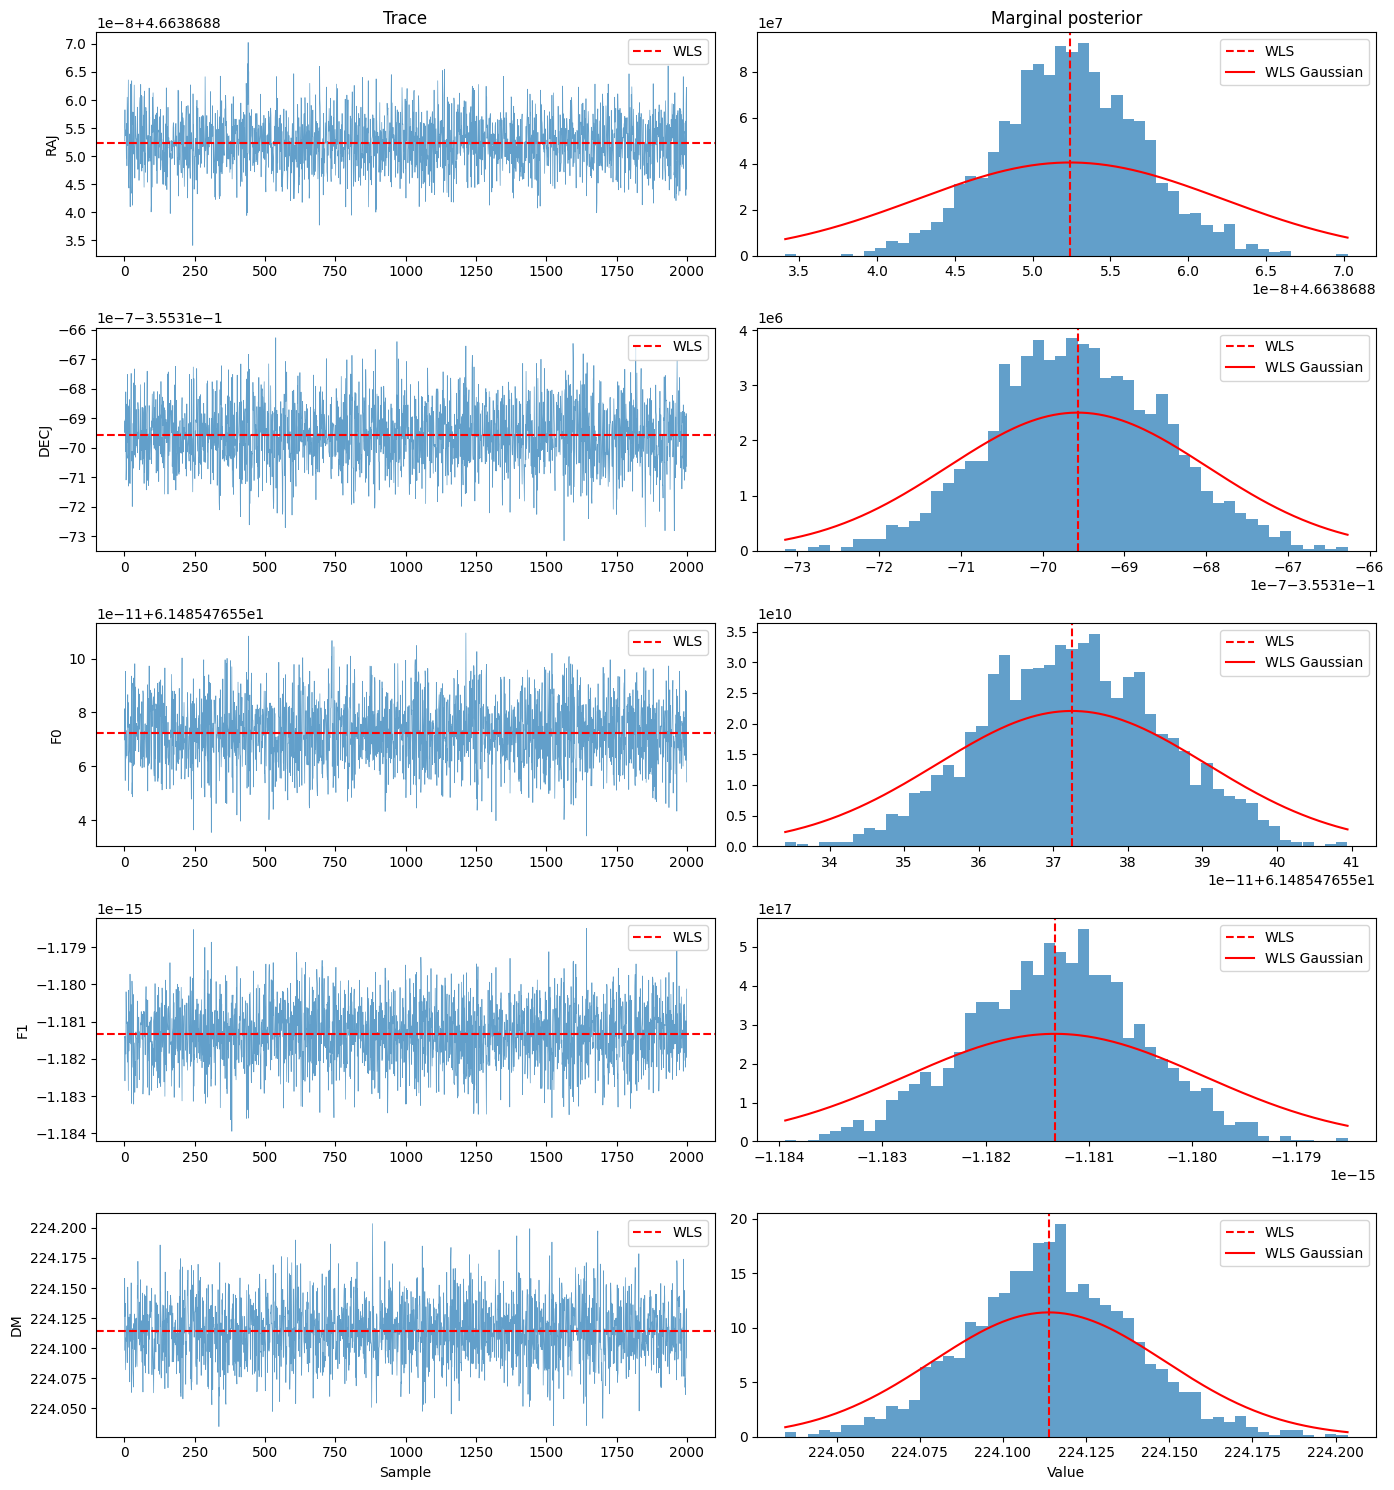

In [7]:
free_names = wls_params.free_names()
samples_np = np.array(samples)

# Trace plots
fig, axes = plt.subplots(len(free_names), 2, figsize=(14, 3 * len(free_names)))

for i, name in enumerate(free_names):
    # Trace
    axes[i, 0].plot(samples_np[:, i], alpha=0.7, linewidth=0.5)
    axes[i, 0].axhline(float(wls_free[i]), color="r", linestyle="--", label="WLS")
    axes[i, 0].set_ylabel(name)
    axes[i, 0].legend(loc="upper right")

    # Marginal histogram
    axes[i, 1].hist(samples_np[:, i], bins=50, density=True, alpha=0.7)
    axes[i, 1].axvline(float(wls_free[i]), color="r", linestyle="--", label="WLS")
    # Overlay Gaussian from WLS uncertainty
    x = np.linspace(samples_np[:, i].min(), samples_np[:, i].max(), 200)
    sigma = float(wls_unc[i])
    mu = float(wls_free[i])
    axes[i, 1].plot(x, np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi)),
                    "r-", label="WLS Gaussian")
    axes[i, 1].legend(loc="upper right")

axes[0, 0].set_title("Trace")
axes[0, 1].set_title("Marginal posterior")
axes[-1, 0].set_xlabel("Sample")
axes[-1, 1].set_xlabel("Value")
plt.tight_layout()
plt.show()

In [8]:
# Compare posterior summary to WLS estimates
post_mean = np.mean(samples_np, axis=0)
post_std = np.std(samples_np, axis=0)

print(f"{'Parameter':<10} {'WLS Mean':>20} {'WLS Unc':>15} {'Post Mean':>20} {'Post Std':>15} {'Diff (sigma)':>12}")
print("-" * 93)
for i, name in enumerate(free_names):
    diff_sigma = (post_mean[i] - float(wls_free[i])) / float(wls_unc[i])
    print(f"{name:<10} {float(wls_free[i]):>20.10g} {float(wls_unc[i]):>15.4g} "
          f"{post_mean[i]:>20.10g} {post_std[i]:>15.4g} {diff_sigma:>12.2f}")

Parameter              WLS Mean         WLS Unc            Post Mean        Post Std Diff (sigma)
---------------------------------------------------------------------------------------------
RAJ                 4.663868852       9.835e-09          4.663868852       4.642e-09        -0.00
DECJ              -0.3553169572       1.593e-07        -0.3553169569       1.058e-07         0.00
F0                  61.48547655       1.809e-11          61.48547655       1.202e-11         0.00
F1             -1.181331693e-15       1.442e-18      -1.18133362e-15       8.292e-19        -0.00
DM                  224.1137963         0.03494          224.1142454         0.02495         0.01


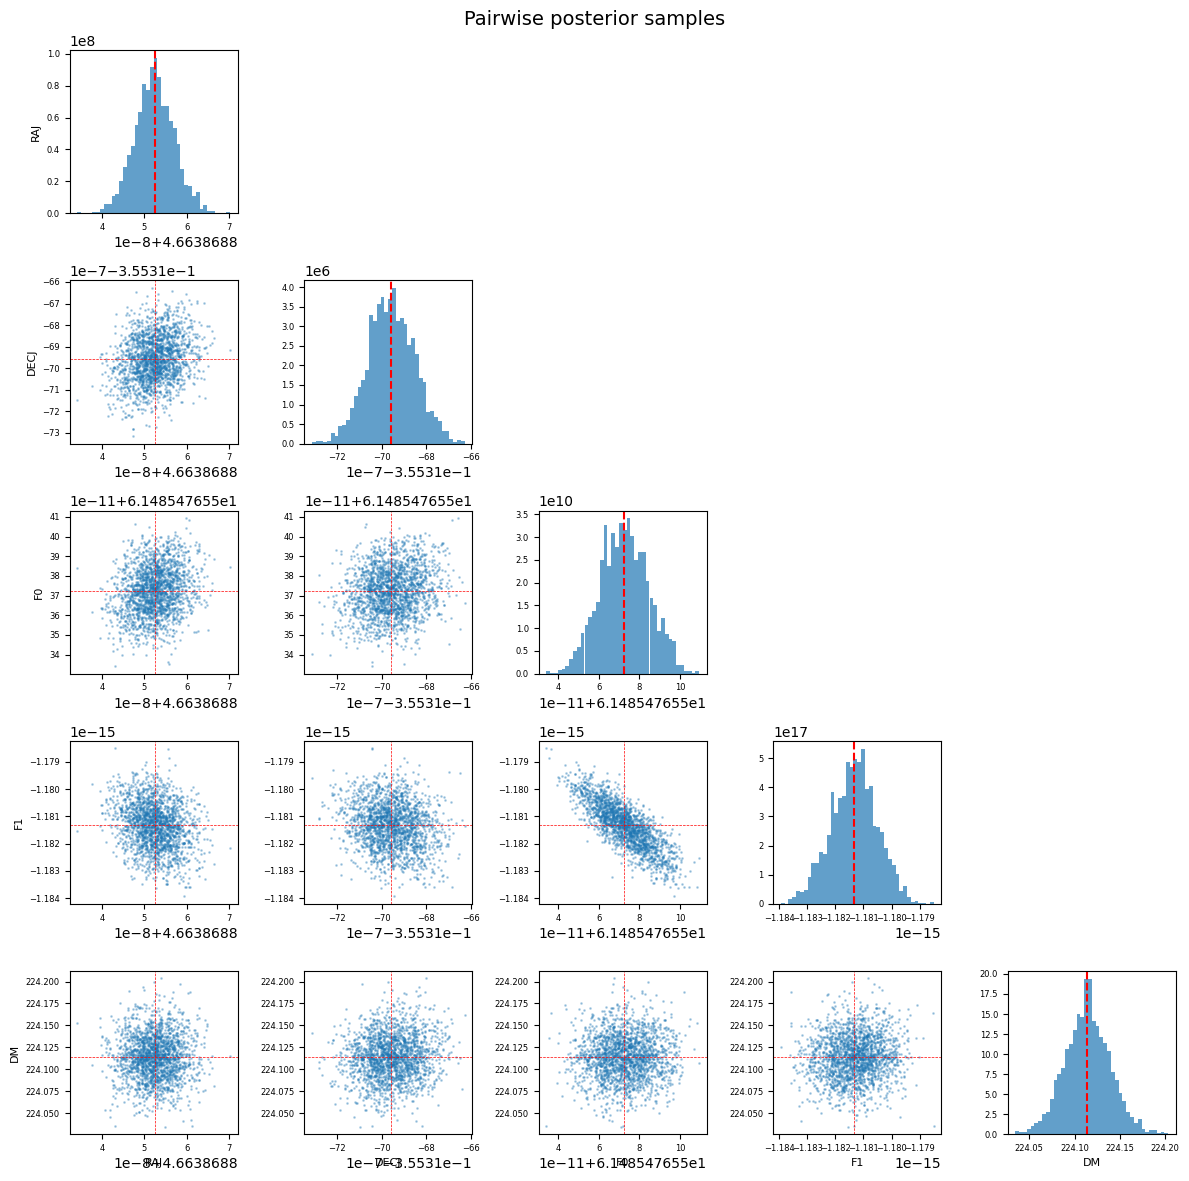

In [9]:
# Pairwise scatter (corner-style)
n_params = len(free_names)
fig, axes = plt.subplots(n_params, n_params, figsize=(12, 12))

for i in range(n_params):
    for j in range(n_params):
        ax = axes[i, j]
        if j > i:
            ax.set_visible(False)
        elif i == j:
            ax.hist(samples_np[:, i], bins=40, density=True, alpha=0.7)
            ax.axvline(float(wls_free[i]), color="r", linestyle="--")
        else:
            ax.scatter(samples_np[:, j], samples_np[:, i], s=1, alpha=0.3)
            ax.axhline(float(wls_free[i]), color="r", linestyle="--", linewidth=0.5)
            ax.axvline(float(wls_free[j]), color="r", linestyle="--", linewidth=0.5)

        if i == n_params - 1:
            ax.set_xlabel(free_names[j], fontsize=8)
        if j == 0:
            ax.set_ylabel(free_names[i], fontsize=8)
        ax.tick_params(labelsize=6)

plt.suptitle("Pairwise posterior samples", fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
# NUTS diagnostics
num_steps = np.array(extra["num_steps"])
print(f"Acceptance rate: {acceptance_rate:.2%}")
print(f"Mean integration steps: {num_steps.mean():.1f}")
print(f"Max integration steps: {int(num_steps.max())}")
print(f"Divergent transitions: {int(np.array(extra['diverging']).sum())}")

Acceptance rate: 89.41%
Mean integration steps: 5.8
Max integration steps: 15
Divergent transitions: 0
